Total Records: 213705
Total Deaths: 30066
Total Recoveries: 183639


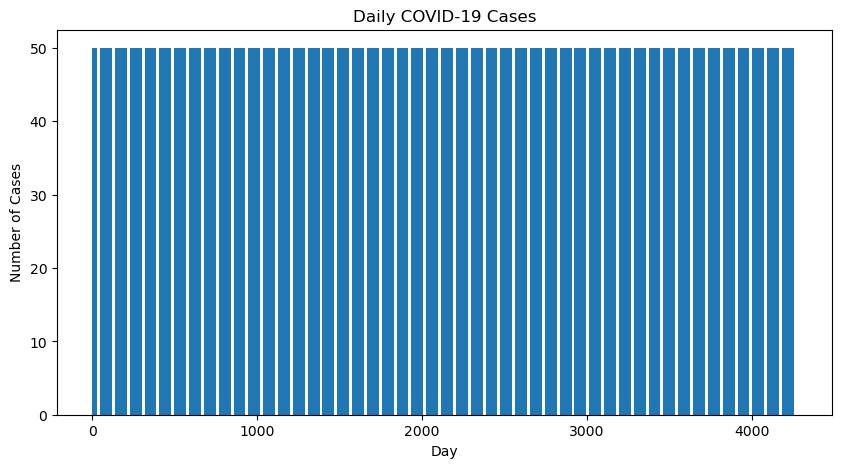

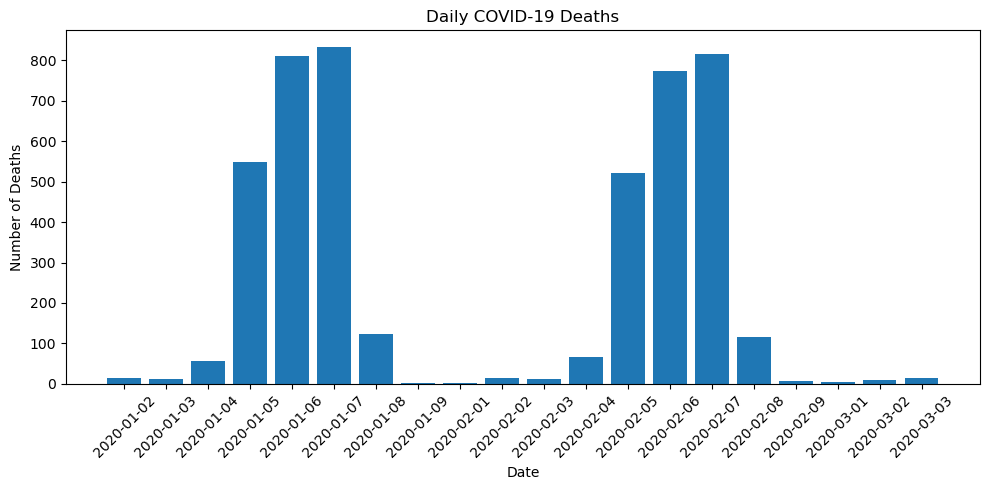

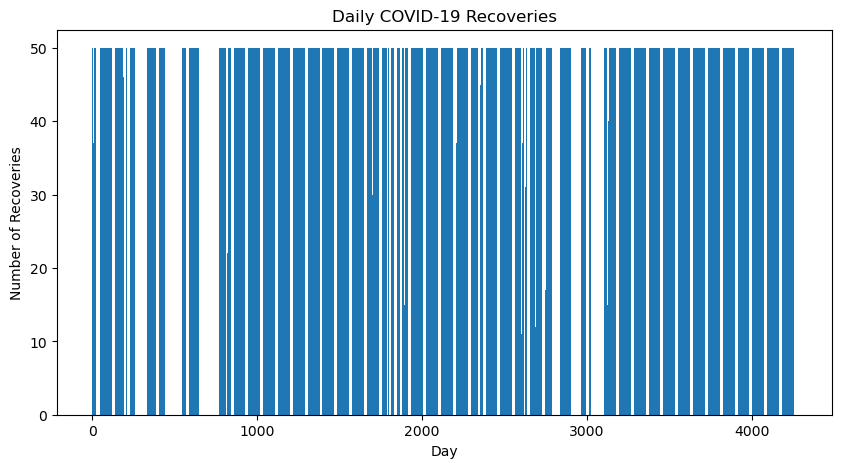

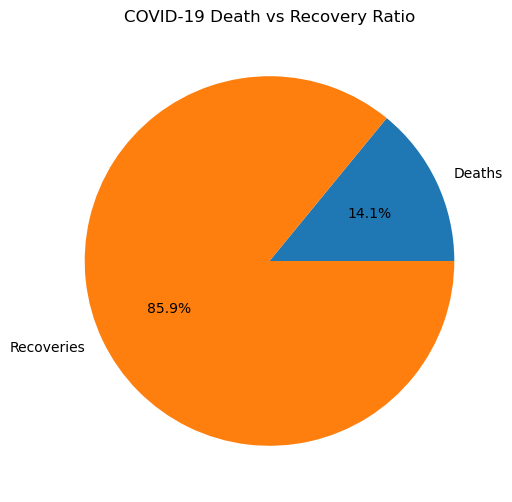

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Dataset
data = pd.read_csv(r"A:\data science\task1\Covid Data.csv")

# Clean column names
data.columns = data.columns.str.strip().str.upper()

# 2. Clean Data

# Replace invalid values
data.replace(["9999-99-99", 97, 98, 99], pd.NA, inplace=True)

# Convert date column
data['DATE_DIED'] = pd.to_datetime(data['DATE_DIED'], errors='coerce')

# Create death column
data['DIED'] = data['DATE_DIED'].notna()

# Remove duplicates
data = data.drop_duplicates()

# Clean age column
data['AGE'] = pd.to_numeric(data['AGE'], errors='coerce')
data = data.dropna(subset=['AGE'])

# Reset index
data = data.reset_index(drop=True)

print("Total Records:", len(data))
print("Total Deaths:", data['DIED'].sum())
print("Total Recoveries:", len(data) - data['DIED'].sum())


# 3. Daily Cases

daily_cases = data.groupby(data.index // 50).size()

plt.figure(figsize=(10,5))
plt.bar(daily_cases.index, daily_cases.values)

plt.title("Daily COVID-19 Cases")
plt.xlabel("Day")
plt.ylabel("Number of Cases")

plt.show()

# 4. Daily Deaths

daily_deaths = data[data['DIED'] == True]['DATE_DIED'].value_counts().sort_index()

# Limit dates for readability
daily_deaths = daily_deaths.head(20)

plt.figure(figsize=(10,5))
plt.bar(daily_deaths.index.astype(str), daily_deaths.values)

plt.title("Daily COVID-19 Deaths")
plt.xlabel("Date")
plt.ylabel("Number of Deaths")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Daily Recoveries

recovered = data[data['DIED'] == False]
daily_recovery = recovered.groupby(recovered.index // 50).size()

plt.figure(figsize=(10,5))
plt.bar(daily_recovery.index, daily_recovery.values)

plt.title("Daily COVID-19 Recoveries")
plt.xlabel("Day")
plt.ylabel("Number of Recoveries")

plt.show()

# 6. Pie Chart

total_cases = len(data)
total_deaths = data['DIED'].sum()
total_recovered = total_cases - total_deaths

sizes = [total_deaths, total_recovered]
labels = ['Deaths', 'Recoveries']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.title("COVID-19 Death vs Recovery Ratio")

plt.show()